# 04 — Root Cause Analysis
Explore root cause inference, action plan generation, and ROI prediction for a sample hotel.

In [1]:
import sys, pathlib
ROOT = str(pathlib.Path().resolve().parent)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import matplotlib.pyplot as plt

from src.data_processing.data_loader import load_hotel_by_name, get_hotel_list
from src.data_processing.data_cleaner import clean_reviews
from src.data_processing.feature_extractor import add_topic_indicator_columns
from src.analysis.root_cause_analyzer import infer_root_causes
from src.analysis.impact_calculator import build_impact_table, rank_topics_by_impact
from src.planning.action_generator import ActionPlanGenerator
from src.planning.roi_predictor import calculate_roi

# Change this to any hotel in the dataset
HOTEL = get_hotel_list()[0]
NUM_ROOMS = 80
print(f'Analysing: {HOTEL}')

18:22:01 [INFO] src.data_processing.data_loader: Loading 'main' dataset from: D:\HOTELINSIGHT\data\raw\Hotel_Reviews.csv
18:22:04 [INFO] src.data_processing.data_loader: Loaded 515738 rows, 17 columns.
D:\HOTELINSIGHT\src\utils\date_utils.py:63: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, infer_datetime_format=True, errors="coerce")
18:22:05 [INFO] src.data_processing.data_loader: Found 1492 unique hotels.


Analysing: 11 Cadogan Gardens


## 1. Load and prepare hotel data

In [2]:
raw      = load_hotel_by_name(HOTEL)
cleaned  = clean_reviews(raw)
hotel_df = add_topic_indicator_columns(cleaned)
print(f'Reviews: {len(hotel_df):,} | Avg rating: {hotel_df["rating"].mean():.2f}')
hotel_df[['date', 'rating', 'review_text']].head(3)

18:22:05 [INFO] src.data_processing.data_loader: Loading 'main' dataset from: D:\HOTELINSIGHT\data\raw\Hotel_Reviews.csv
18:22:08 [INFO] src.data_processing.data_loader: Loaded 515738 rows, 17 columns.
D:\HOTELINSIGHT\src\utils\date_utils.py:63: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, infer_datetime_format=True, errors="coerce")
18:22:09 [INFO] src.data_processing.data_loader: Loaded 159 reviews for '11 Cadogan Gardens'.
18:22:09 [INFO] src.data_processing.data_cleaner: Starting review cleaning.  Input rows: 159
18:22:09 [INFO] src.data_processing.data_cleaner: Dropped 0 duplicate rows.
18:22:09 [INFO] src.data_processing.data_cleaner: Dropped 1 rows with empty review text.
18:22:09 [INFO] src.data_processing.data_cleaner: Cleaned data

Reviews: 158 | Avg rating: 4.42


,date,rating,review_text
0,2017-08-03,4.8,Thought the prise of drinks at the bar a littl...
1,2017-07-21,4.4,Nothing in particular just the usual problems ...
2,2017-07-16,4.6,I found the floors in the corridors to be a bi...


## 2. Impact table — which topics hurt ratings most?

In [3]:
impact_tbl = build_impact_table(hotel_df)
impact_tbl.sort_values('impact', ascending=False)

,topic,complaint_count,complaint_rate,avg_rating_with,avg_rating_without,impact
0,cleanliness,0,0.0,None,4.42,0.0
1,staff,0,0.0,None,4.42,0.0
2,maintenance,0,0.0,None,4.42,0.0
3,noise,0,0.0,None,4.42,0.0
4,wifi,0,0.0,None,4.42,0.0
5,breakfast,0,0.0,None,4.42,0.0
6,value,0,0.0,None,4.42,0.0
7,location,0,0.0,None,4.42,0.0


## 3. Visualise impact

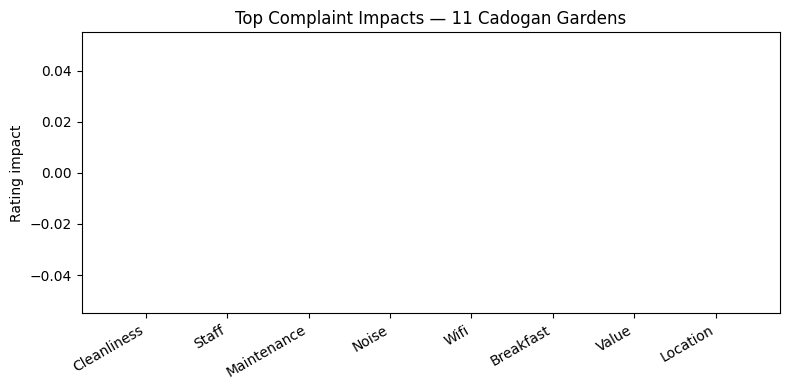

In [4]:
top_impacts = impact_tbl.sort_values('impact', ascending=False).head(8)
plt.figure(figsize=(8, 4))
plt.bar(top_impacts['topic'].str.title(), top_impacts['impact'], color='firebrick', edgecolor='white')
plt.ylabel('Rating impact')
plt.title(f'Top Complaint Impacts — {HOTEL}')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4. Root cause analysis for the top topic

In [5]:
ranked   = rank_topics_by_impact(hotel_df)
top_topic = ranked[0][0] if ranked else 'cleanliness'
print(f'Top topic: {top_topic}')

root_causes = infer_root_causes(hotel_df, top_topic)
rc_df = pd.DataFrame([{
    'Cause':       rc['cause'].replace('_', ' ').title(),
    'Confidence':  f"{rc['confidence']:.0f}%",
    'Description': rc['description']
} for rc in root_causes])
rc_df

18:22:09 [INFO] src.analysis.root_cause_analyzer: No 'cleanliness' complaints found in dataset.


Top topic: cleanliness


""


## 5. Evidence snippets

In [6]:
for rc in root_causes[:3]:
    print(f'\n── {rc["cause"]} ({rc["confidence"]:.0f}%) ──')
    for ev in rc['evidence'][:3]:
        print(f'  • "{ev}"')

## 6. Generate action plan

In [7]:
gen  = ActionPlanGenerator()
plan = gen.generate_plan(HOTEL, top_topic, root_causes, num_rooms=NUM_ROOMS)

for bucket, label in [('immediate_actions', 'Immediate'), ('short_term_actions', 'Short-Term'), ('long_term_actions', 'Long-Term')]:
    print(f'\n── {label} ──')
    for a in plan[bucket]:
        print(f'  [{a["cost"]}] {a["description"]} ({a["timeline"]})')

tc = plan['total_cost']
print(f'\nTotal: one-time=£{tc["one_time"]:,.0f}  monthly=£{tc["monthly"]:,.0f}  3m=£{tc["three_month_total"]:,.0f}')

18:22:09 [INFO] src.planning.action_generator: ActionPlanGenerator ready with 7 root-cause templates.



── Immediate ──

── Short-Term ──

── Long-Term ──

Total: one-time=£0  monthly=£0  3m=£0


## 7. ROI prediction

In [8]:
roi = calculate_roi(HOTEL, top_topic, plan, num_rooms=NUM_ROOMS, avg_room_rate=130, current_occupancy=0.68)
for k, v in roi.items():
    print(f'  {k:30s}: {v}')

18:22:09 [INFO] src.planning.roi_predictor: Calculating ROI for '11 Cadogan Gardens' – topic 'cleanliness'.
18:22:09 [INFO] src.data_processing.data_loader: Loading 'main' dataset from: D:\HOTELINSIGHT\data\raw\Hotel_Reviews.csv
18:22:12 [INFO] src.data_processing.data_loader: Loaded 515738 rows, 17 columns.
D:\HOTELINSIGHT\src\utils\date_utils.py:63: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  return pd.to_datetime(series, infer_datetime_format=True, errors="coerce")
18:22:12 [INFO] src.data_processing.data_loader: Loaded 159 reviews for '11 Cadogan Gardens'.
18:22:12 [INFO] src.data_processing.data_cleaner: Starting review cleaning.  Input rows: 159
18:22:12 [INFO] src.data_processing.data_cleaner: Dropped 0 duplicate rows.
18:22:12 [INFO] src.data_processing.data_cl

  current_rating                : 4.42
  expected_rating               : 4.42
  rating_improvement            : 0.0
  current_occupancy             : 68.0%
  expected_occupancy            : 68.0%
  current_monthly_revenue       : £212,160
  improved_monthly_revenue      : £212,160
  monthly_revenue_increase      : £0
  total_investment              : £0
  returns_3_months              : £0
  net_profit_3_months           : £0
  roi_percentage                : 0.0%
  payback_months                : inf
